# Task 2 — ML Analysis

Time-series gaps, message classification, topic modelling, sentiment analysis, and MLflow logging.

In [13]:
import os
import sys

import matplotlib.pyplot as plt
import nltk
import seaborn as sns

%load_ext autoreload
%autoreload 2

rpath = os.path.abspath('..')
if rpath not in sys.path:
    sys.path.insert(0, rpath)

from src.loader import SlackDataLoader
from src.analysis.time_gaps import get_time_gap_histograms
from src.models.classifier import train_message_classifier, build_labeled_frame
from src.models.topic_model import get_top_topics_by_channel
from src.models.sentiment import daily_sentiment_trend

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

sns.set_theme(style='whitegrid')
DATA_PATH = os.path.join(rpath, 'data', 'anonymized')
MLFLOW_DIR = os.path.join(rpath, 'mlruns')
os.makedirs(MLFLOW_DIR, exist_ok=True)

In [5]:
loader = SlackDataLoader(DATA_PATH)
df = loader.get_all_messages()
print(f'Loaded {len(df):,} messages from {df["channel"].nunique()} channels')

Loaded 18,945 messages from 35 channels


## 1. Time difference histograms

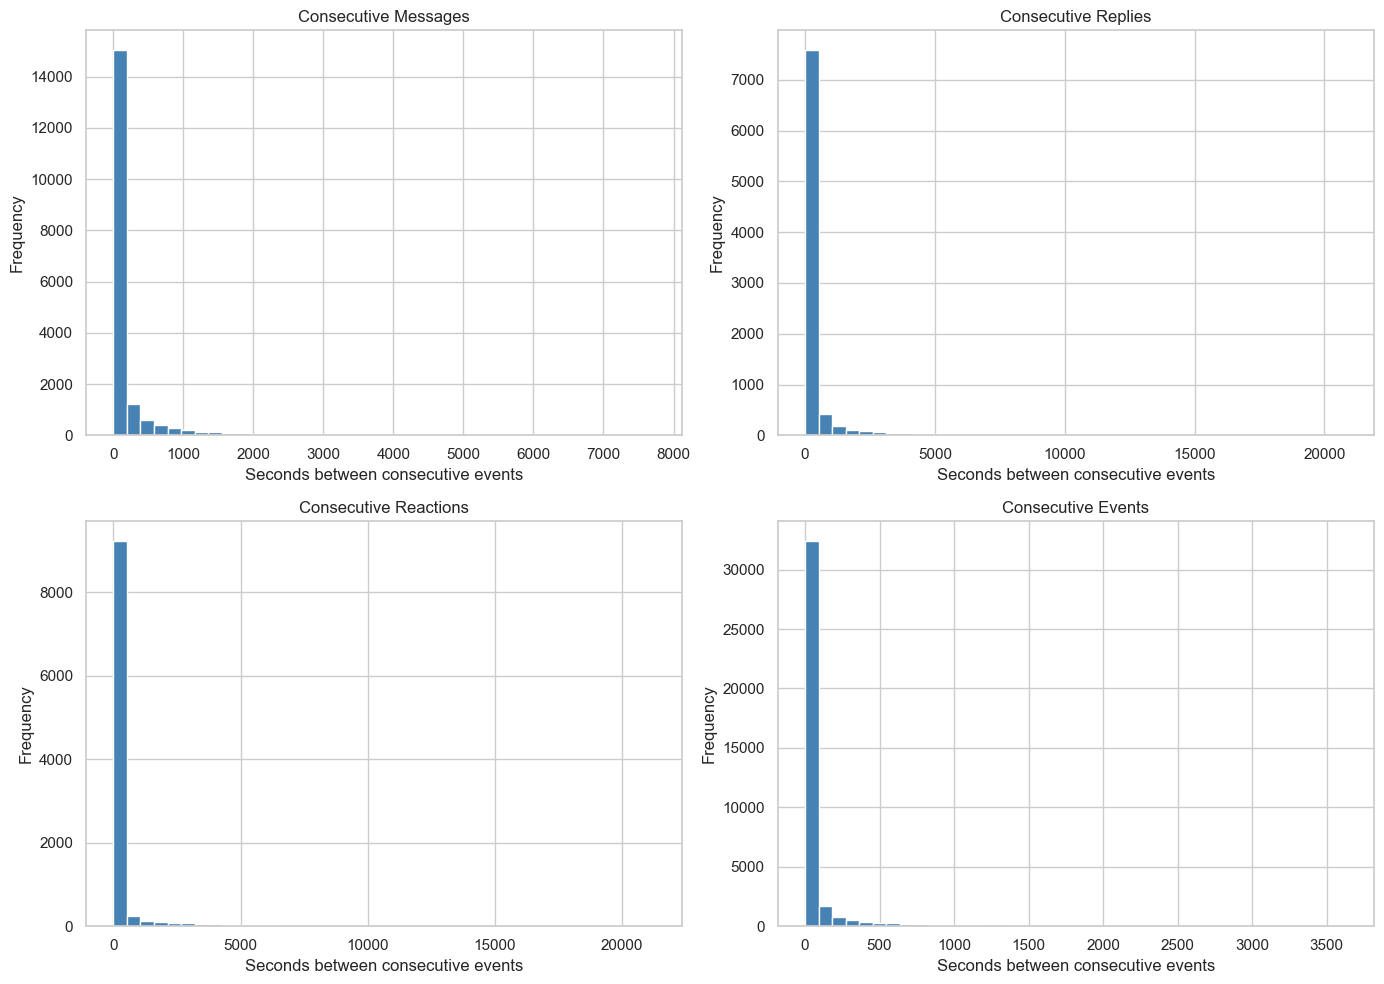

In [ ]:
gaps = get_time_gap_histograms(df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (title, series) in zip(axes.flatten(), gaps.items()):
    if series.empty:
        ax.set_title(f'{title} (no data)')
        continue
    clipped = series[series <= series.quantile(0.99)]
    ax.hist(clipped, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(title.replace('_', ' ').title())
    ax.set_xlabel('Seconds between consecutive events')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 2. Message classification

In [9]:
pipeline, labeled_df, metrics = train_message_classifier(df)
print('Label distribution:')
print(labeled_df['label'].value_counts())
print(f"\nTest accuracy: {metrics['accuracy']:.3f}")

Label distribution:
Answer                    7048
Comment-Non-Technical     3697
Question-Non-technical    2620
Other                     2537
Comment-Technical          438
Question-Technical         432
Name: label, dtype: int64

Test accuracy: 0.657


/Users/tesfamariamasfaw/Documents/tes/ML projects/slack-analysis/.venv/lib/python3.10/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/Users/tesfamariamasfaw/Documents/tes/ML projects/slack-analysis/.venv/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


## 3. Top 10 topics per channel

In [15]:
import importlib
from src.models import topic_model
importlib.reload(topic_model)
from src.models.topic_model import get_top_topics_by_channel

topics_df = get_top_topics_by_channel(df, num_topics=10)
if topics_df.empty:
    print('No topics could be modelled.')
else:
    for channel in topics_df['channel'].unique()[:5]:
        print(f'\n### #{channel}')
        display(topics_df[topics_df['channel'] == channel].head(10))


### #ab_test-group


,channel,topic_id,top_words
0,ab_test-group,0,"dvc, data, folder, ..., file, remote, storage,..."
1,ab_test-group,1,"data, split, yeah, version, work, model, using..."
2,ab_test-group,2,"okay, request, pull, merge, task, time, tasks,..."
3,ab_test-group,3,"add, merged, guys, task, code, thank, someone,..."
4,ab_test-group,4,"work, mlflow, start, n't, understand, model, f..."
5,ab_test-group,5,"working, great, clean, testing, scripts, branc..."
6,ab_test-group,6,"repo, first, right, branches, hello, branch, t..."
7,ab_test-group,7,"repo, work, task, fork, cml, name, created, ca..."
8,ab_test-group,8,"branch, see, share, n't, let, michelle, set, dvc"
9,ab_test-group,9,"yes, push, n't, johnson, help, going, could, task"



### #adludios-challange


,channel,topic_id,top_words
10,adludios-challange,0,"n't, like, need, code, want, talk, give, diagram"
11,adludios-challange,1,"think, frame, present, working, n't, start, fe..."
12,adludios-challange,2,"guys, clap, hello, group, nice, file, availabl..."
13,adludios-challange,3,"extracted, extraction, home, jason, jackson, o..."
14,adludios-challange,4,"logo, also, great, okay, detection, might, fac..."
15,adludios-challange,5,"thanks, presentation, instance, working, slide..."
16,adludios-challange,6,"yes, yesterday, bro, need, idea, think, logos,..."
17,adludios-challange,7,"data, install, meeting, pip, daniel, downloade..."
18,adludios-challange,8,"good, n't, try, thank, meet, faces, time, okay"
19,adludios-challange,9,"image, right, template, activate, environment,..."



### #all-broadcast


,channel,topic_id,top_words
20,all-broadcast,0,"one, trainees, photo, n't, award, team, group,..."
21,all-broadcast,1,"time, session, next, please, platform, utc, no..."
22,all-broadcast,2,"deadline, please, kindly, clock, timer, submis..."
23,all-broadcast,3,"week, schedule, standup, kindly, find, link, j..."
24,all-broadcast,4,"notice, monday, utc, group, yes, sorry, link, ..."
25,all-broadcast,5,"join, email, please, job, check, welcome, 've,..."
26,all-broadcast,6,"standup, join, today, right, link, point, remi..."
27,all-broadcast,7,"please, talk, guest, graduation, ceremony, joa..."
28,all-broadcast,8,"contest, timed, utc, week, joanne, note, pleas..."
29,all-broadcast,9,"challenge, work, independent, please, time, ut..."



### #all-career-exercises


,channel,topic_id,top_words
30,all-career-exercises,0,"submission, exercise, submit, please, week, li..."
31,all-career-exercises,1,"questions, like, academy, point, profile, joan..."
32,all-career-exercises,2,"thanks, yes, work, skills, mock, please, email..."
33,all-career-exercises,3,"talk, group, report, debate, link, think, read..."
34,all-career-exercises,4,"morning, good, n't, one, would, time, profile,..."
35,all-career-exercises,5,"session, really, questions, debate, vs., right..."
36,all-career-exercises,6,"joy, please, one, required, experience, sure, ..."
37,all-career-exercises,7,"meeting, calendly, could, schedule, screenshot..."
38,all-career-exercises,8,"job, questions, n't, question, well, face, fir..."
39,all-career-exercises,9,"thank, questions, n't, good, think, ask, quest..."



### #all-community-building


,channel,topic_id,top_words
40,all-community-building,0,"joanne, academy, make, first, time, sure, one,..."
41,all-community-building,1,"hot, questions, clap, smiley, good, today, ann..."
42,all-community-building,2,"hello, high, low, week, happy, day, last, chal..."
43,all-community-building,3,"face, yes, lol, guess, 're, thinking, sunglass..."
44,all-community-building,4,"grinning, love, get, rest, ask, help, joanne0,..."
45,all-community-building,5,"n't, know, one, want, think, really, like, grin"
46,all-community-building,6,"today, guys, thank, let, would, miss, post, group"
47,all-community-building,7,"joy, laughing, rolling, floor, good, morning, ..."
48,all-community-building,8,"man, face, bro, smiling, back, made, alien, real"
49,all-community-building,9,"cbs, session, time, please, next, community, r..."


## 4. Sentiment trend over days since training start

2026/06/17 20:21:16 INFO mlflow.tracking.fluent: Experiment with name 'slack-sentiment' does not exist. Creating a new experiment.


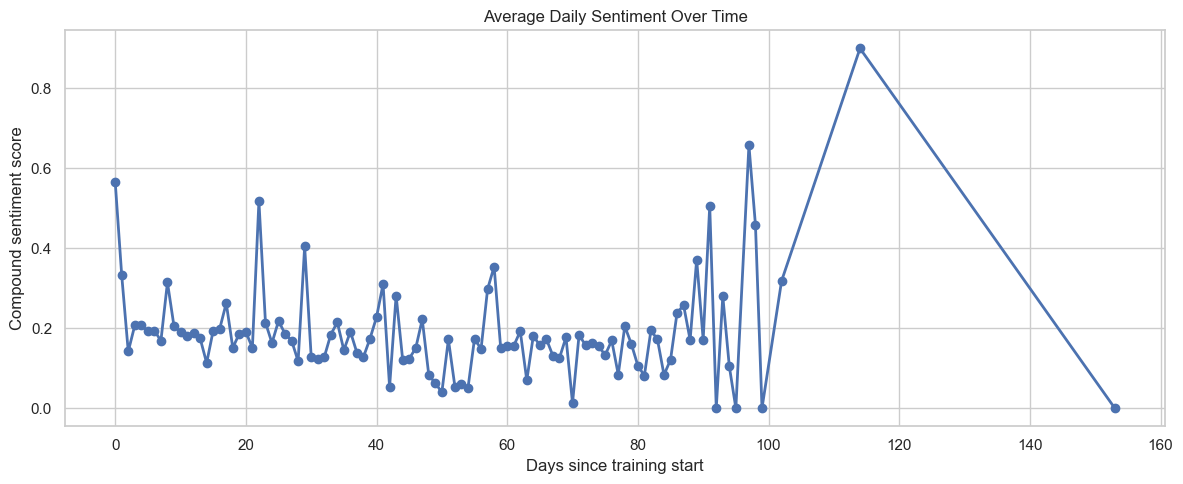

,days_since_start,sentiment,message_count,combined_text
0,0,0.566333,9,i am glad to make it to the week 1-4 program. ...
1,1,0.332025,8,"hi all, looking forward to starting together, ..."
2,2,0.141743,251,hi all - note that you have been shared a week...
3,3,0.207062,488,*1o academy batch 6 : slack workspace channels...
4,4,0.206907,337,good morning all <!here> ! trust everyone is d...


In [16]:
sentiment_df = daily_sentiment_trend(df)

plt.figure(figsize=(12, 5))
plt.plot(sentiment_df['days_since_start'], sentiment_df['sentiment'], marker='o', linewidth=2)
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Days since training start')
plt.ylabel('Compound sentiment score')
plt.tight_layout()
plt.show()

sentiment_df.head()

## Observations

### 1. Time-gap histograms
All four histograms are **strongly right-skewed**: most gaps are very short, with a long tail of rare long pauses.

- **Consecutive messages** — median ~33s; most messages arrive within minutes, but occasional multi-day gaps exist.
- **Consecutive replies** — similar shape, slightly longer median (~45s); thread replies often come quickly but can stall for hours.
- **Consecutive reactions** — heavily peaked at **0s**; many reactions happen in bursts on the same timestamp.
- **Consecutive events (all types)** — also peaked near 0 because reactions and rapid message bursts dominate overall activity.

### 2. Message classification
**Answer** is the largest class (~37%, 7,048 messages), followed by **Comment-Non-Technical** (~20%) and **Question-Non-technical** (~14%). **Technical** messages (Question + Comment) are a small minority (~4% combined). The TF-IDF + logistic regression model reached **65.7% test accuracy** on these weak labels — reasonable given that some labels (e.g. Answer) rely on thread metadata the model never sees.

### 3. Topics in the busiest channel (`all-community-building`, 8,264 messages)
LDA topics reflect **community and onboarding** rather than technical content:

- Hotseat / academy announcements (`joanne`, `hotseat`, `announce`)
- Daily check-ins (`hello`, `happy`, `week`, `challenge`)
- Informal engagement (`clap`, `smiley`, `lol`, `grinning`)

Other active channels (e.g. `ab_test-group`, `kafka_de`) show more **project and tooling** vocabulary (data, model, pipeline, DVC).

### 4. Sentiment trend
Daily compound sentiment **fluctuates** over the ~153-day training window (mean ≈ 0.19). There is **no clear linear trend** (correlation with days ≈ 0.005). The first week averaged ~0.26 and the last week ~0.33, so sentiment is mildly more positive toward the end, but day-to-day swings (including a drop to 0.0 around day 92 and a peak of ~0.90 around day 114) show that mood varies with cohort events rather than improving steadily.